4.3. Local response normalization

To repoduce : 4.3. Local response normalization



In [1]:
import os
# os.environ["KERAS_BACKEND"] = "jax"

In [2]:
import keras
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from keras.src.legacy.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

#### Load Dataset

In [3]:

# (x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data() # The source url through put is slow

# Loading CIFAR-10 dataset from Local directory, download zip file from https://www.kaggle.com/competitions/cifar-10/data

dir = "../../Datasets/cifar-10"
train_data_path = os.path.join(dir, "train")
test_data_path = os.path.join(dir, "test")
train_csv_path = os.path.join(dir, "trainLabels.csv")
train_data_path, train_csv_path

('cifar-10\\train', 'cifar-10\\trainLabels.csv')

In [4]:
df = pd.read_csv(train_csv_path)
df['id'] = df['id'].astype(str) + '.png'
datagen = ImageDataGenerator(rescale=1./255)

train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

train_data = datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=train_data_path,
    x_col="id",
    y_col="label",
    target_size=(32, 32),
    batch_size=32,
    class_mode="categorical"
)

val_data = datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=train_data_path,
    x_col="id",
    y_col="label",
    target_size=(32, 32),
    batch_size=32,
    class_mode="categorical"
)

test_datagen = ImageDataGenerator(rescale=1./255)
test_data = test_datagen.flow_from_directory(
    directory=dir,
    classes=['test'],
    target_size=(32, 32),
    batch_size=32,
    class_mode=None,
    shuffle=False
)

Found 40000 validated image filenames belonging to 10 classes.
Found 10000 validated image filenames belonging to 10 classes.
Found 300000 images belonging to 1 classes.


In [5]:
images, labels = next(train_data)

print("Images batch shape:", images.shape)
print("Labels batch shape:", labels.shape)
print("Class indices mapping:", train_data.class_indices)

Images batch shape: (32, 32, 32, 3)
Labels batch shape: (32, 10)
Class indices mapping: {'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}


[0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]


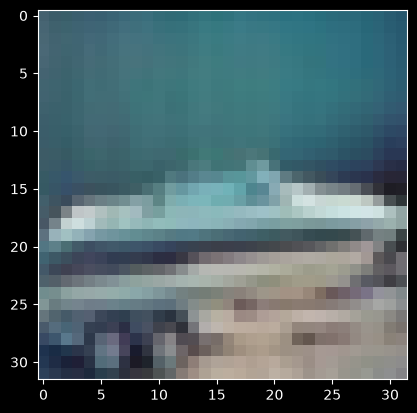

In [6]:
i = 1
print(labels[i])
plt.imshow(images[i])


In [7]:
images = next(test_data)

print("Images batch shape:", images.shape)

Images batch shape: (32, 32, 32, 3)


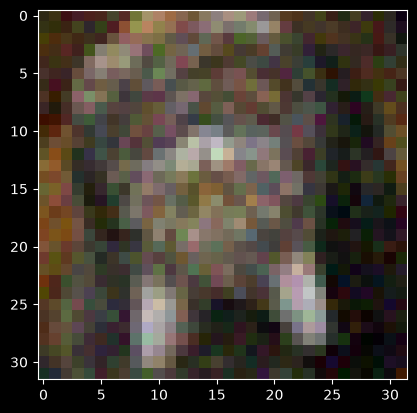

In [8]:
i = 10
plt.imshow(images[i])

#### Model with no LRN

In [9]:
model_no_lrn = keras.Sequential([
    keras.layers.Input(shape=(32, 32, 3)),
    keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),
    keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),
    keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    keras.layers.Flatten(),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10, activation='softmax')
])

model_no_lrn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,440,778 (16.94 MB)

 Trainable params: 4,440,778 (16.94 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model_no_lrn.compile(
    optimizer=keras.optimizers.Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_no_lrn = model_no_lrn.fit(train_data, epochs=10, validation_data=val_data)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 55s 43ms/step - accuracy: 0.4216 - loss: 1.5793 - val_accuracy: 0.5585 - val_loss: 1.2177
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 52s 42ms/step - accuracy: 0.6004 - loss: 1.1294 - val_accuracy: 0.6448 - val_loss: 0.9901
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 55s 44ms/step - accuracy: 0.6745 - loss: 0.9248 - val_accuracy: 0.6998 - val_loss: 0.8587
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 54s 43ms/step - accuracy: 0.7232 - loss: 0.7915 - val_accuracy: 0.7192 - val_loss: 0.7948
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 53s 43ms/step - accuracy: 0.7596 - loss: 0.6813 - val_accuracy: 0.7344 - val_loss: 0.7686
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 54s 43ms/step - accuracy: 0.7974 - loss: 0.5841 - val_accuracy: 0.7458 - val_loss: 0.7576
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 54s 43ms/step - accuracy: 0.8245 - loss: 0.4946 - val_accuracy: 0.7210 - val_loss: 0.8898
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 54s 43ms/step - accuracy: 0.8538 -

#### Model with LRN

In [11]:
### Custom Layer for LRN
lrn_layer_dummy = keras.layers.Lambda(lambda x: tf.nn.local_response_normalization(x,
            depth_radius=2, bias=2.0, alpha=10e-4, beta=0.75),name="LRN1")
            # n = 5,        k = 2   ,alpha = 10e-4, beta = 0.75 : from paper
            # Passing 2 on depth radius means it checks 2 channels to the left and 2 channels to the right, making the total window size n = 5

def get_lrn_layer(name):
    return keras.layers.Lambda(
        lambda x: tf.nn.local_response_normalization(x, depth_radius=2, bias=2.0, alpha=1e-4, beta=0.75),name=name)

In [12]:
model_with_lrn = keras.Sequential([
    keras.layers.Input(shape=(32, 32, 3)),
    keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    get_lrn_layer('lrn_1'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),
    keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    get_lrn_layer('lrn_2'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),
    keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    keras.layers.Flatten(),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10, activation='softmax')
])


model_with_lrn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lrn_1 (Lambda)                  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lrn_2 (Lambda)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,440,778 (16.94 MB)

 Trainable params: 4,440,778 (16.94 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model_with_lrn.compile(
    optimizer=keras.optimizers.Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_with_lrn = model_with_lrn.fit(train_data, epochs=10, validation_data=val_data)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 68s 53ms/step - accuracy: 0.4100 - loss: 1.6098 - val_accuracy: 0.5298 - val_loss: 1.2894
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 65s 52ms/step - accuracy: 0.5765 - loss: 1.1940 - val_accuracy: 0.6239 - val_loss: 1.0334
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 81s 51ms/step - accuracy: 0.6507 - loss: 0.9843 - val_accuracy: 0.6753 - val_loss: 0.9228
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 69s 55ms/step - accuracy: 0.7057 - loss: 0.8400 - val_accuracy: 0.6824 - val_loss: 0.9014
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 93s 74ms/step - accuracy: 0.7424 - loss: 0.7341 - val_accuracy: 0.7229 - val_loss: 0.8170
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 86s 69ms/step - accuracy: 0.7696 - loss: 0.6461 - val_accuracy: 0.7301 - val_loss: 0.7826
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 75s 60ms/step - accuracy: 0.8015 - loss: 0.5607 - val_accuracy: 0.7471 - val_loss: 0.7545
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 72s 57ms/step - accuracy: 0.8294 -

#### Comparisions

[]

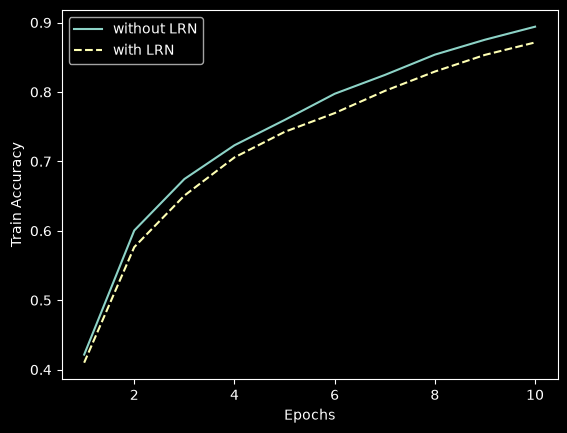

In [14]:
epoch_tanh = list(range(1, len(history_no_lrn.history["val_accuracy"])+1))
epoch_relu = list(range(1, len(history_with_lrn.history["val_accuracy"])+1))
plt.plot(epoch_tanh, history_no_lrn.history["val_accuracy"], '-', label="without LRN")
plt.plot(epoch_relu, history_with_lrn.history["val_accuracy"], '--', label="with LRN")
plt.legend()
plt.ylabel("Validation Accuracy")
plt.xlabel("Epochs")
plt.plot()
# Image below might not be updated for validation data

[]

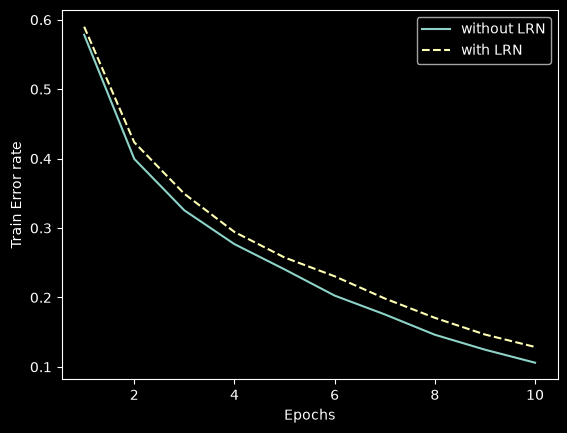

In [15]:
epoch_tanh = list(range(1, len(history_no_lrn.history["val_accuracy"])+1))
epoch_relu = list(range(1, len(history_with_lrn.history["val_accuracy"])+1))
plt.plot(epoch_tanh, 1- np.array(history_no_lrn.history["val_accuracy"]), '-', label="without LRN")
plt.plot(epoch_relu, 1- np.array(history_with_lrn.history["val_accuracy"]), '--', label="with LRN")
plt.legend()
plt.ylabel("Validation Error rate")
plt.xlabel("Epochs")
plt.plot()
# Image below might not be updated for validation data

### Testing and Submission

In [18]:
class_map = {i:j for j, i in train_data.class_indices.items()}
class_mapper = lambda i: class_map[i]

filenames = test_data.filenames
ids = [int(os.path.basename(f).split('.')[0]) for f in filenames]

In [19]:
prediction_no_lrn = model_no_lrn.predict(test_data)
predict_no_lrn_class = np.argmax(prediction_no_lrn, axis=1)
submission_no_lrn = list(map(class_mapper, list(map(int, list(predict_no_lrn_class)))))
df_no_lrn = pd.DataFrame({"id": ids, "label": submission_no_lrn})
df_no_lrn.sort_values(by="id", inplace=True)
df_no_lrn.set_index("id", inplace=True)
df_no_lrn.to_csv("submission_without_LRN.csv")

9375/9375 ━━━━━━━━━━━━━━━━━━━━ 204s 22ms/step


In [20]:
prediction_with_lrn = model_with_lrn.predict(test_data)
predict_with_lrn_class = np.argmax(prediction_with_lrn, axis=1)
submission_with_lrn = list(map(class_mapper, list(map(int, list(predict_with_lrn_class)))))
df_with_lrn = pd.DataFrame({"id": ids, "label": submission_with_lrn})
df_with_lrn.sort_values(by="id", inplace=True)
df_with_lrn.set_index("id", inplace=True)
df_with_lrn.to_csv("submission_with_LRN.csv")


9375/9375 ━━━━━━━━━━━━━━━━━━━━ 254s 27ms/step


### Conclution

From paper :
We also verified the effectiveness of this scheme on the CIFAR-10 dataset:

A four-layer CNN achieved a 13% test error rate without normalization and 11% with normalization.


Our Observation :

Ran 2 models of 4 layer CNN. One without LRN and one with LRN.

LRN was introduced in code as custom layer. and ran both models for full 10 Epochs.

Predicted with x test data and submitted on to kaggel competetion of https://www.kaggle.com/competitions/cifar-10/overview

Prediction from Model with no LRN got 73.43% in competetion

Prediction from Model with LRN got 74.07% in competetion

Paper claim that Model with LRN reduces error rate by 2% was varified.

We observed 0.64% error rate reduction with LRN. (Maybe we wil notice near 2% if we train for large epochs)

Note : Modern Deep learning no longer uses LRN as they are replaced by better Method - Batch Normalization